# Image Captioning Project Pipeline
This notebook implements an end-to-end deep learning framework for **Image Captioning** based on the following structural workflow:

1. **Problem Understanding** (Current Step)
2. Dataset Collection
3. Data Preprocessing
4. Text Cleaning
5. Vocabulary Creation
6. Tokenization
7. Image Feature Extraction (Encoder)
8. Caption Generator Model (Decoder)
9. Data Generator / Batch Pipeline
10. Training Loop
11. Loss Calculation
12. Backpropagation
13. Validation
14. Save Checkpoint
15. Inference / Testing
16. Evaluation
17. Improvement & Optimization

---

## 1. Problem Understanding
The objective of this project is to build an **Encoder-Decoder (CNN-RNN)** architecture that can automatically generate descriptive textual captions for a given input image. 

* **The Input**: A static RGB image tensor.
* **The Output**: A dynamically generated sentence matching human-like descriptions.

### The Mechanism
1. **The Encoder (CNN)** acts as the "eyes" of the network, reading the pixel values and converting them into a high-level visual feature vector.
2. **The Decoder (RNN/LSTM)** acts as the "linguistic brain," taking those visual features and predicting the sequence of words one by one, conditioned on previous states.

In [1]:
import os
import re
import pickle
import numpy as np
from tqdm import tqdm

import tensorflow as tf

from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input

from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.preprocessing.image import img_to_array

from tensorflow.keras.preprocessing.text import Tokenizer

from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.utils import to_categorical

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Embedding
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import add

from tensorflow.keras.callbacks import (
    ModelCheckpoint,
    EarlyStopping,
    ReduceLROnPlateau
)

2026-05-22 04:41:34.204997: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779424894.739506      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779424894.852145      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779424895.980780      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779424895.980877      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779424895.980882      57 computation_placer.cc:177] computation placer alr

## 2. Dataset Collection (Step 2)
In this section, we locate and define our data entry paths:
1. **Images Directory**: The folder containing all raw `.jpg` or `.png` scene images.
2. **Captions File**: The `.txt` or `.csv` file containing the mapping of image filenames to their respective text descriptions.

In [2]:
# --- Step 2: Dataset Path Configuration ---
import os

# आपके सक्रिय Kaggle इनपुट पैनल के अनुसार बिल्कुल सटीक पाथ
IMAGE_DIR = "/kaggle/input/datasets/jaydeepprajapatik/dataset-im"
CAPTIONS_FILE = "/kaggle/input/datasets/jaydeepprajapatik/dataset-im/captions.txt"

print("--- Step 2: Direct Dataset Validation ---")

# सिंटैक्स एरर और पाथ दोनों को एक साथ सही तरीके से चेक करना
try:
    with open(CAPTIONS_FILE, "r") as f:
        print("[SUCCESS] Captions file detected! Quick Preview:")
        for i in range(4):
            print(f.readline().strip())
except FileNotFoundError:
    print("[ERROR] Captions file missing. Printing available root contents:")
    if os.path.exists("/kaggle/input/dataset-im"):
        print(os.listdir("/kaggle/input/dataset-im"))

--- Step 2: Direct Dataset Validation ---
[SUCCESS] Captions file detected! Quick Preview:
image,caption
1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set of stairs in an entry way .
1000268201_693b08cb0e.jpg,A girl going into a wooden building .
1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .


In [57]:
filename = "/kaggle/input/datasets/jaydeepprajapatik/dataset-im/captions.txt"

def load_captions(filename):

    mapping = {}

    with open(filename, 'r', encoding='utf-8') as f:

        next(f)   # skip header

        for line in f:

            tokens = line.strip().split(',')

            if len(tokens) < 2:
                continue

            image_id = tokens[0].strip()

            caption = ",".join(tokens[1:]).strip()

            if image_id not in mapping:
                mapping[image_id] = []

            mapping[image_id].append(caption)

    return mapping

In [58]:
captions = load_captions(filename)

In [59]:
print(list(captions.keys())[:5])

['1000268201_693b08cb0e.jpg', '1001773457_577c3a7d70.jpg', '1002674143_1b742ab4b8.jpg', '1003163366_44323f5815.jpg', '1007129816_e794419615.jpg']


In [60]:
print(list(features.keys())[:5])

['3226254560_2f8ac147ea.jpg', '214543992_ce6c0d9f9b.jpg', '2366643786_9c9a830db8.jpg', '3368819708_0bfa0808f8.jpg', '2190227737_6e0bde2623.jpg']


In [61]:
def clean_caption(caption):

    caption = caption.lower()

    caption = re.sub(r'[^a-z ]', '', caption)

    caption = caption.strip()

    caption = 'startseq ' + caption + ' endseq'

    return caption

In [62]:
captions = load_captions("/kaggle/input/datasets/jaydeepprajapatik/dataset-im/captions.txt")

for key, caps in captions.items():

    captions[key] = [
        clean_caption(c)
        for c in caps
    ]

In [63]:
all_captions = []

for caps in captions.values():
    all_captions.extend(caps)

tokenizer = Tokenizer(oov_token="<unk>")

tokenizer.fit_on_texts(all_captions)

vocab_size = len(tokenizer.word_index) + 1

In [64]:
pickle.dump(
    tokenizer,
    open("tokenizer.pkl", "wb")
)

In [65]:
max_length = max(
    len(caption.split())
    for caption in all_captions
)

print(max_length)

37


In [41]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model

# LOAD PRETRAINED VGG16
base_model = VGG16(
    weights='imagenet'
)

# REMOVE LAST CLASSIFICATION LAYER
model = Model(
    inputs=base_model.input,
    outputs=base_model.layers[-2].output
)

# FREEZE ALL VGG16 LAYERS
for layer in model.layers:
    layer.trainable = False

# VERIFY
print("Trainable Layers:")

for layer in model.layers:
    print(layer.name, layer.trainable)

# SUMMARY
model.summary()

Trainable Layers:
input_layer_13 False
block1_conv1 False
block1_conv2 False
block1_pool False
block2_conv1 False
block2_conv2 False
block2_pool False
block3_conv1 False
block3_conv2 False
block3_conv3 False
block3_pool False
block4_conv1 False
block4_conv2 False
block4_conv3 False
block4_pool False
block5_conv1 False
block5_conv2 False
block5_conv3 False
block5_pool False
flatten False
fc1 False
fc2 False


Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_13 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,260,544 (512.16 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 134,260,544 (512.16 MB)

In [14]:
def extract_features(directory):

    features = {}

    for img_name in tqdm(os.listdir(directory)):

        img_path = os.path.join(directory, img_name)

        image = load_img(
            img_path,
            target_size=(224, 224)
        )

        image = img_to_array(image)

        image = image.reshape(
            (1, image.shape[0], image.shape[1], image.shape[2])
        )

        image = preprocess_input(image)

        feature = model.predict(
            image,
            verbose=0
        )

        image_id = img_name

        features[image_id] = feature

    return features

In [16]:
features = extract_features("/kaggle/input/datasets/jaydeepprajapatik/dataset-im/Images")

  0%|          | 0/8091 [00:00<?, ?it/s]WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
I0000 00:00:1779425126.654059     148 service.cc:152] XLA service 0x7c391c005020 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779425126.654113     148 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1779425126.654123     148 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1779425126.915860     148 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1779425130.344610     148 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
100%|██████████| 8091/8091 [14:34<00:00,  9.25it/s]


In [17]:
pickle.dump(
    features,
    open("features.pkl", "wb")
)

In [70]:
def create_sequences(
    tokenizer,
    max_length,
    captions_list,
    photo,
    vocab_size
):

    X1, X2, y = [], [], []

    for caption in captions_list:

        seq = tokenizer.texts_to_sequences(
            [caption]
        )[0]

        for i in range(1, len(seq)):

            in_seq = seq[:i]

            out_seq = seq[i]

            in_seq = pad_sequences(
                [in_seq],
                maxlen=max_length
            )[0]

            out_seq = to_categorical(
                [out_seq],
                num_classes=vocab_size
            )[0]

            X1.append(photo[0])

            X2.append(in_seq)

            y.append(out_seq)

    return np.array(X1), np.array(X2), np.array(y)

In [71]:
def data_generator(
    captions,
    features,
    tokenizer,
    max_length,
    vocab_size,
    batch_size
):

    image_ids = list(captions.keys())

    while True:

        np.random.shuffle(image_ids)

        for i in range(0, len(image_ids), batch_size):

            batch_ids = image_ids[i:i + batch_size]

            X1, X2, y = [], [], []

            for image_id in batch_ids:

                photo = features[image_id]

                caps = captions[image_id]

                in_img, in_seq, out_word = create_sequences(
                    tokenizer,
                    max_length,
                    caps,
                    photo,
                    vocab_size
                )

                X1.extend(in_img)
                X2.extend(in_seq)
                y.extend(out_word)

            yield (
                (
                    np.array(X1),
                    np.array(X2)
                ),
                np.array(y)
            )

In [72]:
def build_model(vocab_size, max_length):

    # IMAGE FEATURE MODEL
    inputs1 = Input(shape=(4096,))

    fe1 = Dropout(0.5)(inputs1)

    fe2 = Dense(
        256,
        activation='relu'
    )(fe1)

    # TEXT MODEL
    inputs2 = Input(shape=(max_length,))

    se1 = Embedding(
        vocab_size,
        256,
        mask_zero=True
    )(inputs2)

    se2 = Dropout(0.5)(se1)

    se3 = LSTM(
        256,
        dropout=0.3,
        recurrent_dropout=0.3
    )(se2)

    # MERGE
    decoder1 = add([fe2, se3])

    decoder2 = Dense(
        256,
        activation='relu'
    )(decoder1)

    outputs = Dense(
        vocab_size,
        activation='softmax'
    )(decoder2)

    model = Model(
        inputs=[inputs1, inputs2],
        outputs=outputs
    )

    model.compile(
        loss='categorical_crossentropy',
        optimizer='adam'
    )

    return model

In [73]:
caption_model = build_model(
    vocab_size,
    max_length
)

caption_model.summary()

Model: "functional_12"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_21      │ (None, 37)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_20      │ (None, 4096)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_8         │ (None, 37, 256)   │  2,248,192 │ input_layer_21[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_16          │ (None, 4096)      │          0 │ input_layer_20[0… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_17          │ (None, 37, 256)   │          0 │ embedding_8[0][0] │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_8         │ (None, 37)        │          0 │ input_layer_21[0… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_24 (Dense)    │ (None, 256)       │  1,048,832 │ dropout_16[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_8 (LSTM)       │ (None, 256)       │    525,312 │ dropout_17[0][0], │
│                     │                   │            │ not_equal_8[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_8 (Add)         │ (None, 256)       │          0 │ dense_24[0][0],   │
│                     │                   │            │ lstm_8[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_25 (Dense)    │ (None, 256)       │     65,792 │ add_8[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_26 (Dense)    │ (None, 8782)      │  2,256,974 │ dense_25[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 6,145,102 (23.44 MB)

 Trainable params: 6,145,102 (23.44 MB)

 Non-trainable params: 0 (0.00 B)

In [74]:
checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor='val_loss',
    verbose=1,
    save_best_only=True,
    mode='min'
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2,
    min_lr=1e-6
)

In [75]:
image_ids = list(captions.keys())

split = int(len(image_ids) * 0.9)

train_ids = image_ids[:split]

val_ids = image_ids[split:]

In [76]:
train_captions = {
    k: captions[k]
    for k in train_ids
}

val_captions = {
    k: captions[k]
    for k in val_ids
}

In [77]:
batch_size = 32

train_generator = data_generator(
    train_captions,
    features,
    tokenizer,
    max_length,
    vocab_size,
    batch_size
)

val_generator = data_generator(
    val_captions,
    features,
    tokenizer,
    max_length,
    vocab_size,
    batch_size
)

In [78]:
import math

steps_train = math.ceil(
    len(train_ids) / batch_size
)

steps_val = math.ceil(
    len(val_ids) / batch_size
)

In [79]:
batch = next(train_generator)

print(type(batch))
print(len(batch))

<class 'tuple'>
2


In [80]:
history = caption_model.fit(
    train_generator,
    epochs=30,
    steps_per_epoch=steps_train,
    validation_data=val_generator,
    validation_steps=steps_val,
    callbacks=[
        checkpoint,
        early_stop,
        reduce_lr
    ]
)

Epoch 1/30
228/228 ━━━━━━━━━━━━━━━━━━━━ 0s 304ms/step - loss: 5.4515
Epoch 1: val_loss improved from inf to 3.78299, saving model to best_model.keras
228/228 ━━━━━━━━━━━━━━━━━━━━ 81s 340ms/step - loss: 5.4483 - val_loss: 3.7830 - learning_rate: 0.0010
Epoch 2/30
228/228 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step - loss: 3.6061
Epoch 2: val_loss improved from 3.78299 to 3.43830, saving model to best_model.keras
228/228 ━━━━━━━━━━━━━━━━━━━━ 76s 335ms/step - loss: 3.6057 - val_loss: 3.4383 - learning_rate: 0.0010
Epoch 3/30
228/228 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step - loss: 3.1759
Epoch 3: val_loss improved from 3.43830 to 3.31175, saving model to best_model.keras
228/228 ━━━━━━━━━━━━━━━━━━━━ 76s 332ms/step - loss: 3.1758 - val_loss: 3.3118 - learning_rate: 0.0010
Epoch 4/30
228/228 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step - loss: 2.9306
Epoch 4: val_loss improved from 3.31175 to 3.28075, saving model to best_model.keras
228/228 ━━━━━━━━━━━━━━━━━━━━ 75s 330ms/step - loss: 2.9306 - val_loss: 3.2808 - le

# #for testing 

In [100]:
best_model = tf.keras.models.load_model(
    "best_model.keras"
)

In [101]:
import pickle

tokenizer = pickle.load(
    open("tokenizer.pkl", "rb")
)

In [102]:
index_to_word = {
    v:k
    for k,v in tokenizer.word_index.items()
}

In [103]:
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.models import Model

base_model = VGG16(weights='imagenet')

vgg_model = Model(
    inputs=base_model.inputs,
    outputs=base_model.layers[-2].output
)

for layer in vgg_model.layers:
    layer.trainable = False

In [104]:
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.preprocessing.image import img_to_array

from tensorflow.keras.applications.vgg16 import preprocess_input

import numpy as np

In [105]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [106]:
def generate_caption(
    model,
    tokenizer,
    photo,
    max_length
):

    in_text = 'startseq'

    for i in range(max_length):

        sequence = tokenizer.texts_to_sequences(
            [in_text]
        )[0]

        sequence = pad_sequences(
            [sequence],
            maxlen=max_length
        )

        yhat = model.predict(
            [photo, sequence],
            verbose=0
        )

        yhat = np.argmax(yhat)

        word = index_to_word.get(yhat)

        if word is None:
            break

        in_text += ' ' + word

        if word == 'endseq':
            break

    return in_text

# new image 


In [126]:
image_path = "/kaggle/input/datasets/jaydeepprajapatik/dataset-im/Images/1032122270_ea6f0beedb.jpg"

In [127]:
photo = extract_feature(image_path)

In [128]:
caption = generate_caption(
    best_model,
    tokenizer,
    photo,
    max_length
)

In [129]:
caption = caption.replace(
    'startseq',
    ''
)

caption = caption.replace(
    'endseq',
    ''
)

caption = caption.strip()

In [130]:
print("Generated Caption:")
print(caption)

Generated Caption:
two dogs are playing in the grass


In [131]:
import matplotlib.pyplot as plt
from PIL import Image

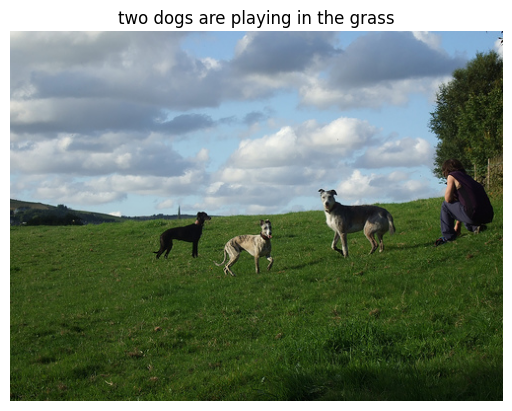

In [132]:
img = Image.open(image_path)

plt.imshow(img)

plt.axis('off')

plt.title(caption)

plt.show()